<a href="https://colab.research.google.com/github/ajmalbiju56/ML/blob/main/covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.9 MB/s eta 0:00:00


# Data preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
pd.options.mode.copy_on_write = True
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/country_wise_latest.csv")
print(df)

         Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
0           Afghanistan      36263    1269      25198    9796        106   
1               Albania       4880     144       2745    1991        117   
2               Algeria      27973    1163      18837    7973        616   
3               Andorra        907      52        803      52         10   
4                Angola        950      41        242     667         18   
..                  ...        ...     ...        ...     ...        ...   
182  West Bank and Gaza      10621      78       3752    6791        152   
183      Western Sahara         10       1          8       1          0   
184               Yemen       1691     483        833     375         10   
185              Zambia       4552     140       2815    1597         71   
186            Zimbabwe       2704      36        542    2126        192   

     New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0         

In [ ]:
df.head(10)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa
5,Antigua and Barbuda,86,3,65,18,4,0,5,3.49,75.58,4.62,76,10,13.16,Americas
6,Argentina,167416,3059,72575,91782,4890,120,2057,1.83,43.35,4.21,130774,36642,28.02,Americas
7,Armenia,37390,711,26665,10014,73,6,187,1.90,71.32,2.67,34981,2409,6.89,Europe
8,Australia,15303,167,9311,5825,368,6,137,1.09,60.84,1.79,12428,2875,23.13,Western Pacific
9,Austria,20558,713,18246,1599,86,1,37,3.47,88.75,3.91,19743,815,4.13,Europe


In [ ]:
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


In [ ]:
df.isnull().sum()

,0
Country/Region,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
New cases,0
New deaths,0
New recovered,0
Deaths / 100 Cases,0
Recovered / 100 Cases,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.dtypes

,0
Country/Region,object
Confirmed,int64
Deaths,int64
Recovered,int64
Active,int64
New cases,int64
New deaths,int64
New recovered,int64
Deaths / 100 Cases,float64
Recovered / 100 Cases,float64


# univariate analysis

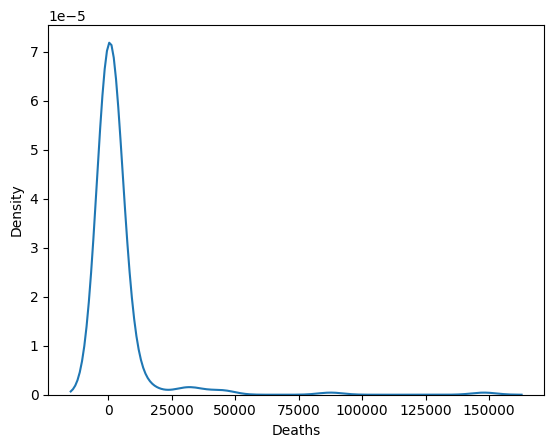

In [ ]:
sns.kdeplot(df['Deaths'])
plt.show()

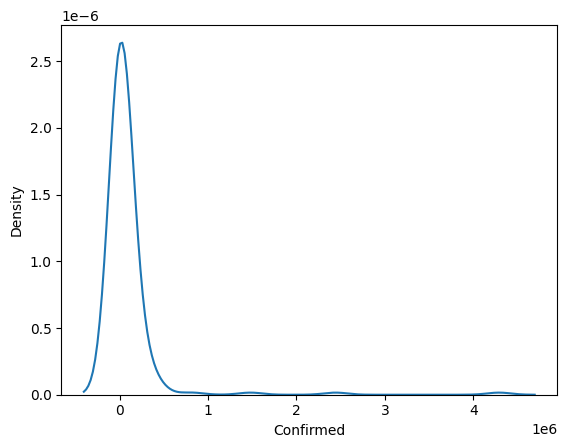

In [ ]:
sns.kdeplot(df['Confirmed'])
plt.show()

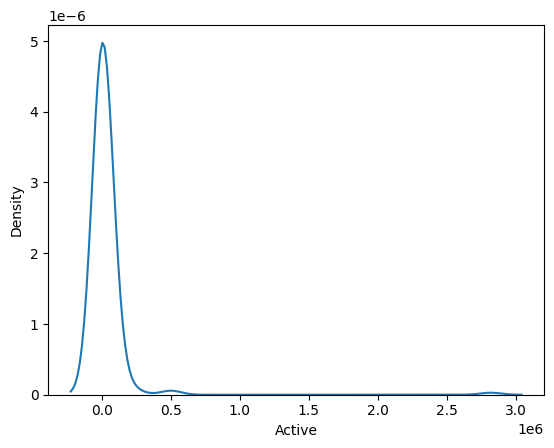

In [ ]:
sns.kdeplot(df['Active'])
plt.show()

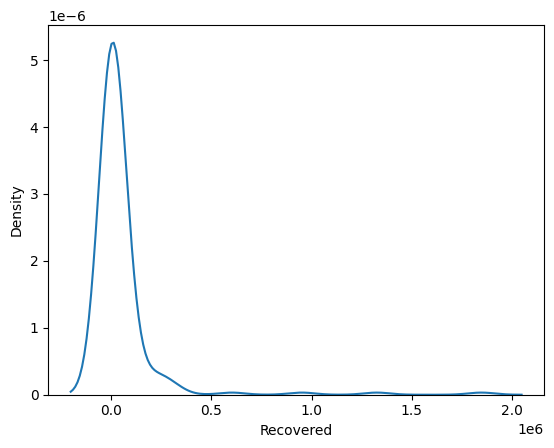

In [ ]:
sns.kdeplot(df['Recovered'])
plt.show()

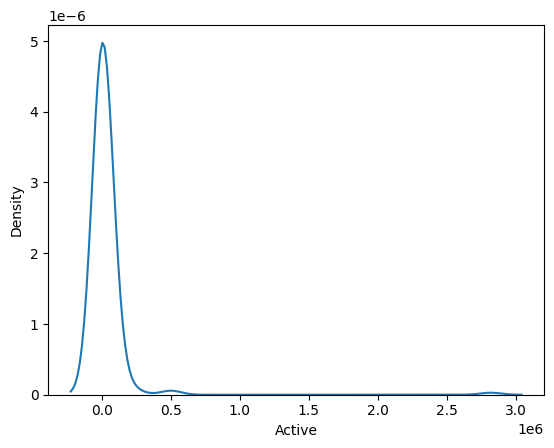

In [ ]:
sns.kdeplot(df['Active'])
plt.show()

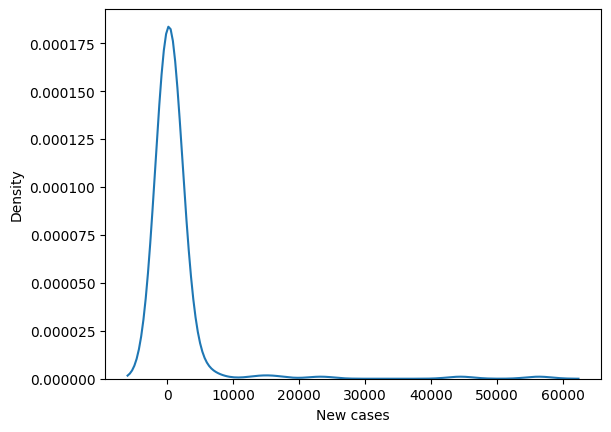

In [ ]:
sns.kdeplot(df['New cases'])
plt.show()

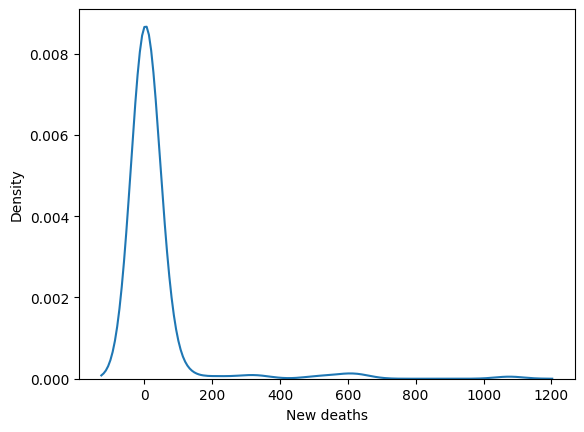

In [ ]:
sns.kdeplot(df['New deaths'])
plt.show()

In [ ]:
df['WHO Region'].nunique()

6

In [ ]:
df['WHO Region'].unique()

array(['Eastern Mediterranean', 'Europe', 'Africa', 'Americas',
       'Western Pacific', 'South-East Asia'], dtype=object)

In [ ]:
df['WHO Region'].value_counts()

,count
WHO Region,
Europe,56
Africa,48
Americas,35
Eastern Mediterranean,22
Western Pacific,16
South-East Asia,10


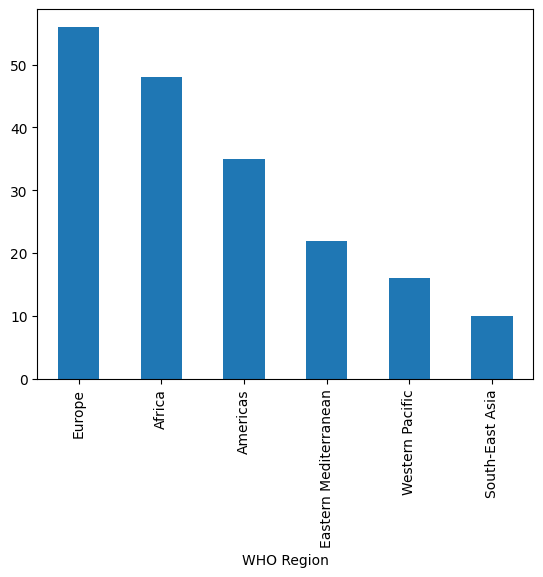

In [ ]:
df['WHO Region'].value_counts().plot(kind='bar')
plt.show()

# bivariate analysis

<function matplotlib.pyplot.show(close=None, block=None)>

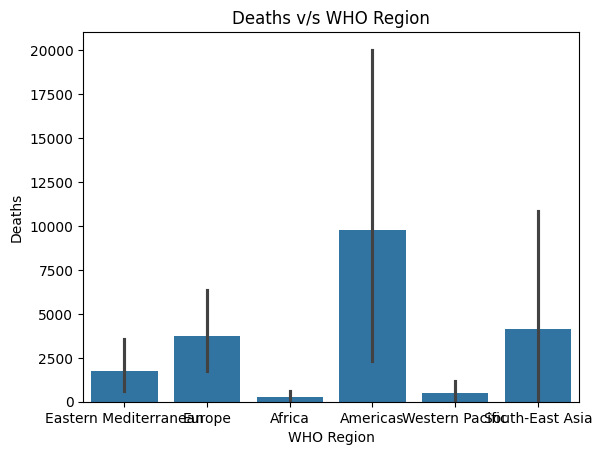

In [ ]:
sns.barplot(data=df,x='WHO Region',y='Deaths')
plt.title("Deaths v/s WHO Region")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

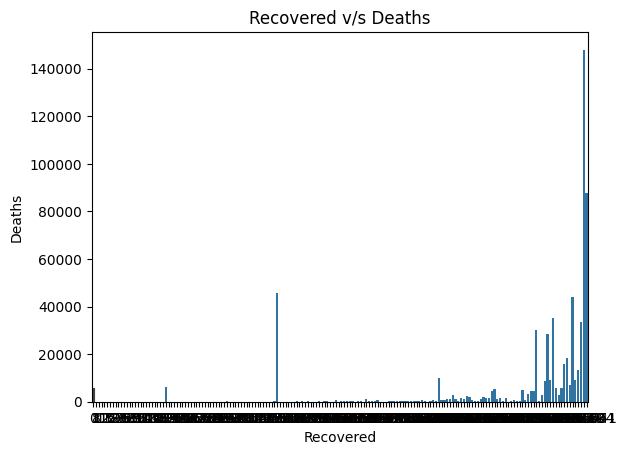

In [ ]:
sns.barplot(data=df,x='Recovered',y='Deaths')
plt.title("Recovered v/s Deaths")
plt.show

Text(0.5, 1.0, 'Active v/s WHO Deaths')

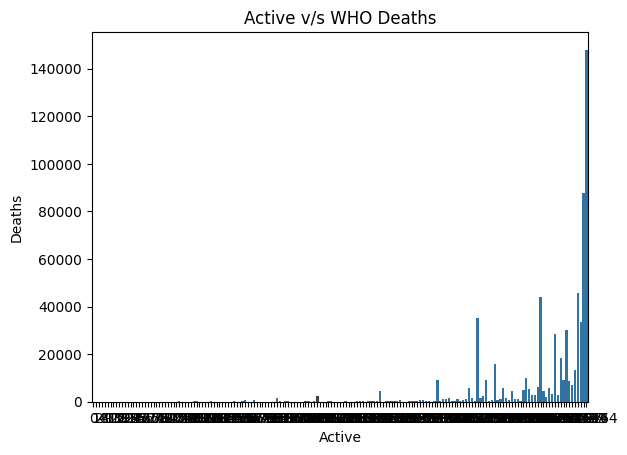

In [ ]:
sns.barplot(data=df,x='Active',y='Deaths')
plt.show
plt.title("Active v/s WHO Deaths")

<function matplotlib.pyplot.show(close=None, block=None)>

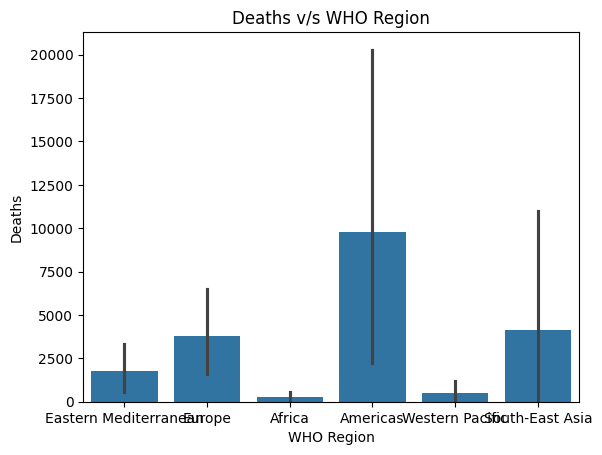

In [ ]:
sns.barplot(data=df,x='WHO Region',y='Deaths')
plt.title("Deaths v/s WHO Region")
plt.show

#multivariate analysis

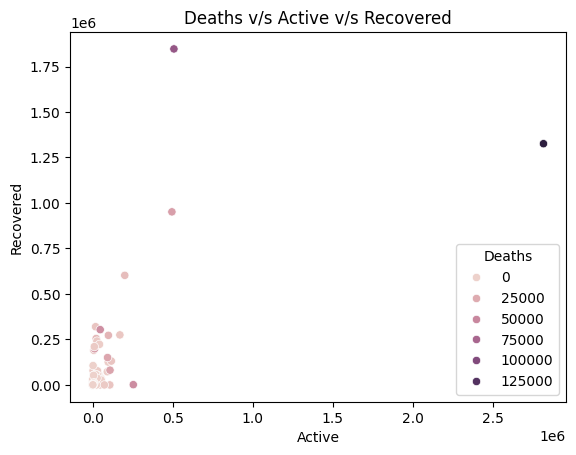

In [ ]:
#multivariate
sns.scatterplot(data=df,x='Active',y='Recovered',hue='Deaths')
plt.title("Deaths v/s Active v/s Recovered")
plt.show()

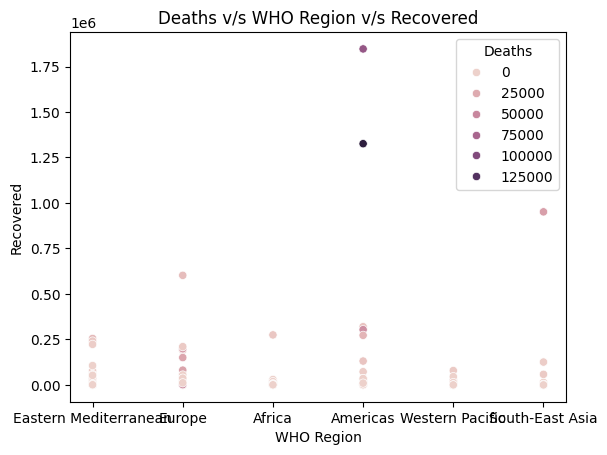

In [ ]:
sns.scatterplot(data=df,x='WHO Region',y='Recovered',hue='Deaths')
plt.title("Deaths v/s WHO Region v/s Recovered")
plt.show()

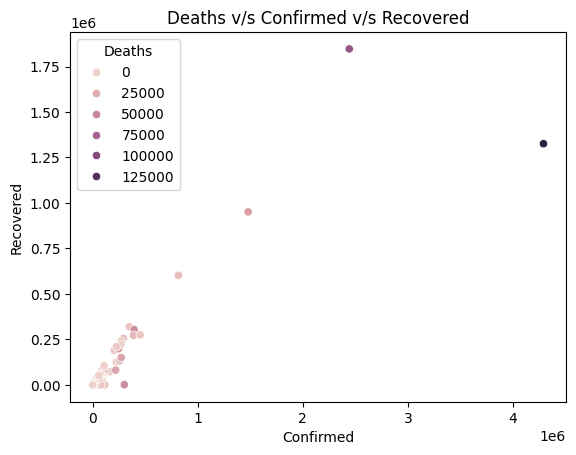

In [ ]:
sns.scatterplot(data=df,x='Confirmed',y='Recovered',hue='Deaths')
plt.title("Deaths v/s Confirmed v/s Recovered")
plt.show()

# Feature Engineering

In [ ]:
df.value_counts()

,,,,,,,,,,,,,,,count
Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,
Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean,1
Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe,1
Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa,1
Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe,1
Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Bank and Gaza,10621,78,3752,6791,152,2,0,0.73,35.33,2.08,8916,1705,19.12,Eastern Mediterranean,1
Western Sahara,10,1,8,1,0,0,0,10.00,80.00,12.50,10,0,0.00,Africa,1
Yemen,1691,483,833,375,10,4,36,28.56,49.26,57.98,1619,72,4.45,Eastern Mediterranean,1


# Data Encoding
* label encoding
*one hot encoding
* target encoding

# target encoding

In [ ]:
print(df.columns.tolist())

['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'Confirmed last week', '1 week change', '1 week % increase', 'WHO Region']


In [ ]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'Confirmed last week', '1 week change', '1 week % increase', 'WHO Region']


In [ ]:
tb_WHORegion = TargetEncoder(cols=['WHO Region'])
df['WHO Region'] = tb_WHORegion.fit_transform(df['WHO Region'], df['Deaths'])

In [ ]:
tb_Country_Region = TargetEncoder(cols=['Country/Region'])
df['Country/Region'] = tb_Country_Region.fit_transform(df['Country/Region'], df['Deaths'])


In [ ]:
df

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,3207.569546,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,2532.649730
1,3061.197513,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,3763.169990
2,3193.778048,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,440.540849
3,3049.227533,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,3763.169990
4,3047.796340,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,440.540849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,3052.610353,10621,78,3752,6791,152,2,0,0.73,35.33,2.08,8916,1705,19.12,2532.649730
183,3042.592001,10,1,8,1,0,0,0,10.00,80.00,12.50,10,0,0.00,440.540849
184,3105.304285,1691,483,833,375,10,4,36,28.56,49.26,57.98,1619,72,4.45,2532.649730
185,3060.677079,4552,140,2815,1597,71,1,465,3.08,61.84,4.97,3326,1226,36.86,440.540849


# Handling outlayers


In [ ]:
# handling outlayers of the  coloumn age
q1 =np.quantile(df['Deaths'],0.25)
q3 =np.quantile(df['Deaths'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True,inplace=True)
for i in range(len(df)):
   if df.loc[i, 'Deaths'] > max_bound:
        df.loc[i, 'Deaths'] = max_bound

<ipython-input-34-923293698>:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1807.25' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'Deaths'] = max_bound


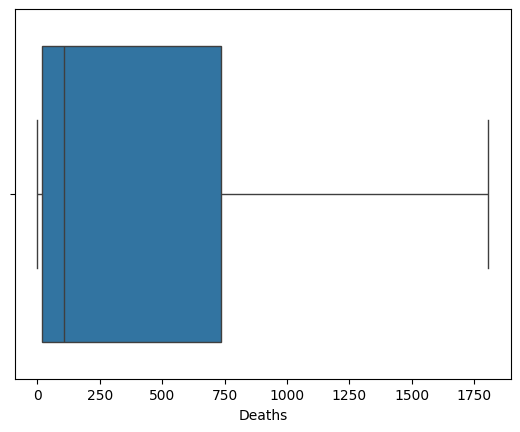

In [ ]:
sns.boxplot(df['Deaths'],orient='h')
plt.show()

In [ ]:
q1 = np.quantile(df['Confirmed'],0.25)
q3 = np.quantile(df['Confirmed'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True, inplace=True)
for i in range(len(df)):
    if df.loc[i, 'Confirmed'] > max_bound:
        df.loc[i, 'Confirmed'] = max_bound

<ipython-input-36-3025951926>:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99480.25' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'Confirmed'] = max_bound


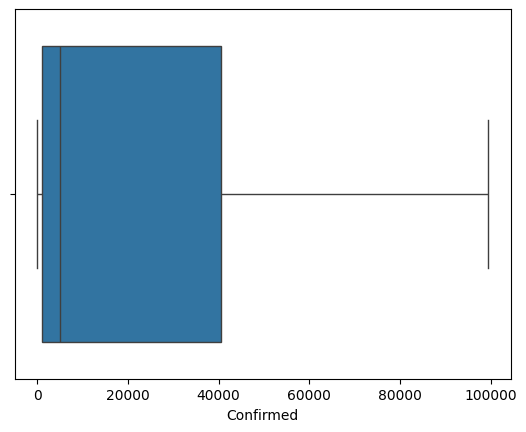

In [ ]:
sns.boxplot(df['Confirmed'],orient='h')
plt.show()

In [ ]:
q1 = np.quantile(df['Recovered'],0.25)
q3 = np.quantile(df['Recovered'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True, inplace=True)
for i in range(len(df)):
    if df.loc[i, 'Recovered'] > max_bound:
        df.loc[i, 'Recovered'] = max_bound

<ipython-input-38-995033767>:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '55575.25' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'Recovered'] = max_bound


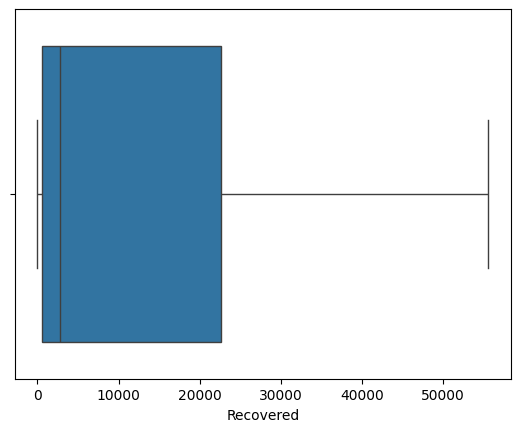

In [ ]:
sns.boxplot(df['Recovered'],orient='h')
plt.show()

In [ ]:
q1 = np.quantile(df['Active'],0.25)
q3 = np.quantile(df['Active'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True, inplace=True)
for i in range(len(df)):
    if df.loc[i, 'Active'] > max_bound:
        df.loc[i, 'Active'] = max_bound

<ipython-input-40-823798965>:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '22660.25' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'Active'] = max_bound


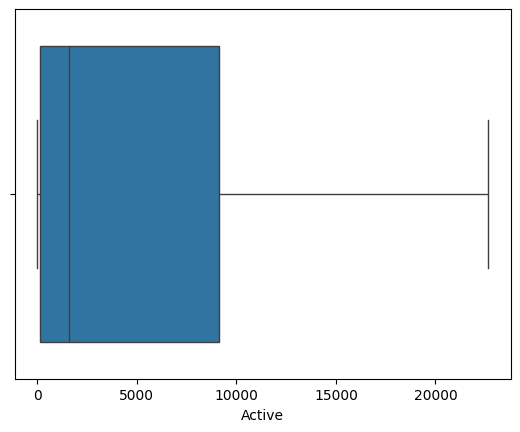

In [ ]:
sns.boxplot(df['Active'],orient='h')
plt.show()

#check corelation

In [ ]:
print(df.dtypes)

Country/Region            float64
Confirmed                 float64
Deaths                    float64
Recovered                 float64
Active                    float64
New cases                   int64
New deaths                  int64
New recovered               int64
Deaths / 100 Cases        float64
Recovered / 100 Cases     float64
Deaths / 100 Recovered    float64
Confirmed last week         int64
1 week change               int64
1 week % increase         float64
WHO Region                float64
dtype: object


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

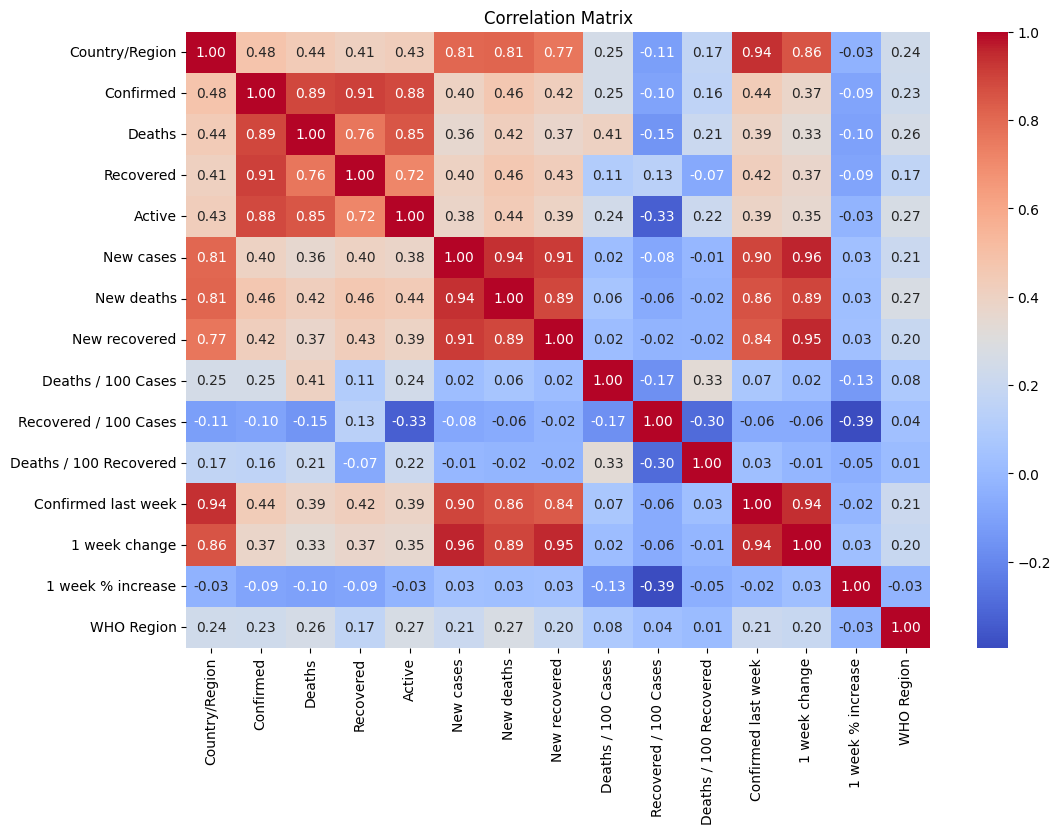

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
selected_cols = ['WHO Region','New deaths','Active','Deaths']

df_new = df[selected_cols]

# checking for multicorelation


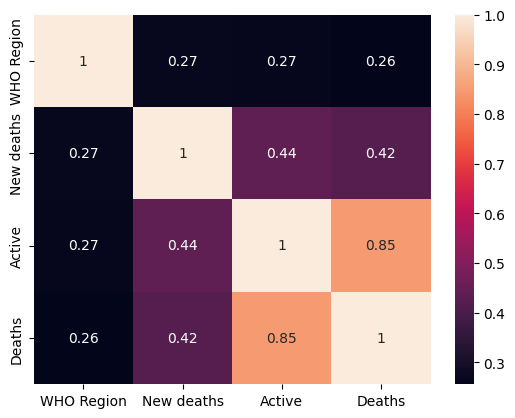

In [ ]:
sns.heatmap(df_new.corr(),annot=True)
plt.show()

# Data scailing

In [ ]:
Active_std = StandardScaler()
df_new['Active'] = Active_std.fit_transform(df_new[['Active']])

In [ ]:
New_std = StandardScaler()
df_new['New deaths'] = New_std.fit_transform(df_new[['New deaths']])

In [ ]:
region_std = StandardScaler()
df_new['WHO Region'] = region_std.fit_transform(df_new[['WHO Region']])

# model building


In [ ]:
df_new

,WHO Region,New deaths,Active,Deaths
0,-0.368434,-0.158352,0.415659,1269.0
1,0.077682,-0.191764,-0.503429,144.0
2,-1.126913,-0.175058,0.200989,1163.0
3,0.077682,-0.241883,-0.731758,52.0
4,-1.126913,-0.233530,-0.659338,41.0
...,...,...,...,...
182,-0.368434,-0.225177,0.061801,78.0
183,-1.126913,-0.241883,-0.737764,1.0
184,-0.368434,-0.208471,-0.693723,483.0
185,-1.126913,-0.233530,-0.549825,140.0


In [ ]:
x=df_new.drop('Deaths',axis=1)
y=df_new['Deaths']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train

,WHO Region,New deaths,Active
95,0.077682,-0.241883,-0.721043
69,1.847192,-0.241883,-0.737882
109,-1.126913,-0.241883,-0.573141
29,-1.126913,-0.241883,-0.648858
126,0.077682,-0.241883,-0.723162
...,...,...,...
106,0.043518,-0.241883,-0.642852
14,1.847192,-0.241883,-0.736822
92,-0.368434,-0.200117,0.308265
179,0.077682,-0.200117,0.370676


In [ ]:
y_train

,Deaths
95,31.0
69,0.0
109,156.0
29,22.0
126,255.0
...,...
106,15.0
14,7.0
92,438.0
179,121.0


In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(149, 3)
(38, 3)
(149,)
(38,)


# knn

In [ ]:
knn = KNeighborsRegressor(n_neighbors=9)
knn.fit(x_train, y_train)

KNeighborsRegressor(n_neighbors=9)

In [ ]:
knn.score(x_train,y_train)

0.7097093522315567

In [ ]:
knn.score(x_test,y_test)

0.7331703239213849

In [ ]:
y_pred=knn.predict(x_test)
y_pred

array([  94.44444444,   88.        ,   25.77777778, 1225.69444444,
       1382.83333333,  686.91666667,   88.        , 1650.11111111,
         25.77777778, 1382.83333333,  367.66666667,  233.        ,
        376.88888889,   18.22222222, 1339.22222222, 1382.83333333,
         39.77777778, 1382.83333333,  971.58333333,   26.77777778,
       1366.16666667,   95.33333333,   11.55555556,   25.77777778,
         23.44444444,   95.55555556,  340.22222222, 1518.63888889,
        971.58333333,  340.22222222,   47.        ,  943.80555556,
       1339.22222222,  125.88888889,   88.        , 1139.63888889,
         39.77777778, 1361.5       ])

In [ ]:
result=pd.DataFrame({'actual':y_test,'predicted':y_pred})
result

,actual,predicted
185,140.00,94.444444
78,10.00,88.000000
55,0.00,25.777778
137,1807.25,1225.694444
161,1807.25,1382.833333
15,538.00,686.916667
75,0.00,88.000000
154,1807.25,1650.111111
122,108.00,25.777778
175,1636.00,1382.833333


In [ ]:
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

In [ ]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MSE: 179129.34553687455
R² Score: 0.7331703239213849


# linear regression

In [ ]:
lin = LinearRegression()
lin.fit(x, y)

LinearRegression()

In [ ]:
print("Intercept:", lin.intercept_)
print("Slope(s):", lin.coef_)

Intercept: 510.1724598930481
Slope(s): [ 16.09524676  39.77820593 570.7908747 ]


In [ ]:
y_pred = lin.predict(x_test)

In [ ]:
lin.score(x_train,y_train)

0.7050196659342745

In [ ]:
lin.score(x_test,y_test)

0.7321004906353203

# decision tree

In [ ]:
dec = DecisionTreeRegressor(random_state = 0)

In [ ]:
dec.fit(x_train, y_train)

DecisionTreeRegressor(random_state=0)

In [ ]:
dec.score(x_train,y_train)

0.9880802700582964

In [ ]:
dec.score(x_test,y_test)

0.6121215563549601

In [ ]:
y_pred = dec.predict(x_test)

In [ ]:
rmse = float(format(np.sqrt(mean_squared_error(y_test, y_pred)), '.3f'))
print("\nRMSE: ", rmse)


RMSE:  510.287


In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("R² Score:", r2)
print("Mean Squared Error:", mse)